In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [2]:
df = pd.read_csv("TCS.csv")
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2004-08-25,TCS,EQ,850.00,1198.7,1198.7,979.00,985.00,987.95,1008.32,17116372,1.725876e+15,NaN,5206360,0.3042
1,2004-08-26,TCS,EQ,987.95,992.0,997.0,975.30,976.85,979.00,985.65,5055400,4.982865e+14,NaN,1294899,0.2561
2,2004-08-27,TCS,EQ,979.00,982.4,982.4,958.55,961.20,962.65,969.94,3830750,3.715586e+14,NaN,976527,0.2549
3,2004-08-30,TCS,EQ,962.65,969.9,990.0,965.00,986.40,986.75,982.65,3058151,3.005106e+14,NaN,701664,0.2294
4,2004-08-31,TCS,EQ,986.75,986.5,990.0,976.00,987.80,988.10,982.18,2649332,2.602133e+14,NaN,695234,0.2624


In [3]:
data = df['Close'].values
data = data.reshape(-1,1)

In [4]:
scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(data)

In [5]:
def create_dataset(data, time_step=10):
    X, y = [], []
    
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step), 0])
        y.append(data[i+time_step, 0])
        
    return np.array(X), np.array(y)

time_step = 10

X, y = create_dataset(data_scaled, time_step)

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,shuffle=False)

In [7]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [8]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(time_step,1)))
model.add(LSTM(50))
model.add(Dense(1))

C:\Users\Shambhavee Gune\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 10, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(optimizer='adam',loss='mean_squared_error', metrics=["mae"])

In [11]:
history = model.fit(X_train,y_train,epochs=50,batch_size=32,validation_data=(X_test, y_test))

Epoch 1/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 0.0088 - mae: 0.0480 - val_loss: 0.0024 - val_mae: 0.0234
Epoch 2/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 4.2381e-04 - mae: 0.0137 - val_loss: 0.0023 - val_mae: 0.0239
Epoch 3/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 4.2382e-04 - mae: 0.0135 - val_loss: 0.0024 - val_mae: 0.0264
Epoch 4/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 4.0922e-04 - mae: 0.0132 - val_loss: 0.0022 - val_mae: 0.0231
Epoch 5/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 4.0306e-04 - mae: 0.0131 - val_loss: 0.0023 - val_mae: 0.0236
Epoch 6/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 4.5541e-04 - mae: 0.0143 - val_loss: 0.0023 - val_mae: 0.0240
Epoch 7/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 3.9580e-04 - mae: 0.0131 - val_loss: 0.0021 - val_mae: 0.0234
Epoch 8/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 3.9380e-04 - mae: 0.0131 - val_loss: 0.0021 - val_mae: 0.0226
Epoch 9/50
104/104 

In [12]:
def plot_results(history):
    results = pd.DataFrame({"Train Loss": history.history['loss'], "Validation Loss": history.history['val_loss'],
              "Train Accuracy": history.history['mae'], "Validation Accuracy": history.history['val_mae']
             })
    fig, ax = plt.subplots(nrows=2, figsize=(16, 9))
    results[["Train Loss", "Validation Loss"]].plot(ax=ax[0])
    results[["Train MAE", "Validation MAE"]].plot(ax=ax[1])
    ax[0].set_xlabel("Epoch")
    ax[1].set_xlabel("Epoch")
    plt.show()

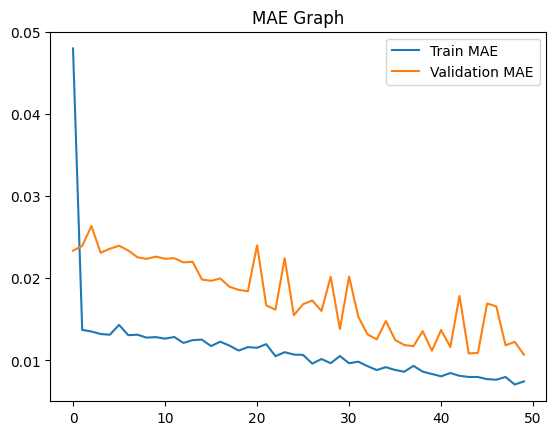

In [14]:
#acc visualization
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.legend()
plt.title("MAE Graph")
plt.show()

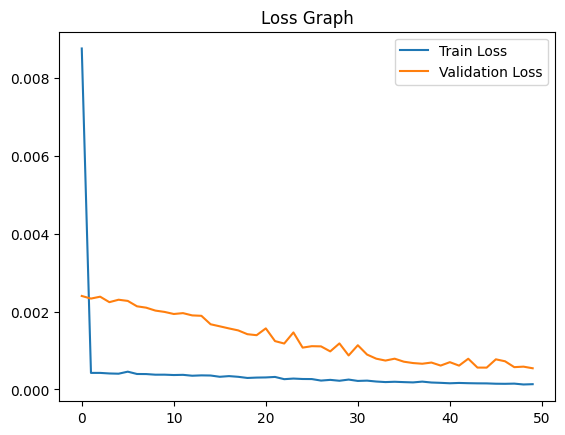

In [15]:
#loss visualization
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()